In [1]:
# === ANALYSIS notebook bootstrap ==========================================
# Loads the dump produced by `neurips_diff_eval.ipynb` -> `dump_simulation_state`
# and exposes every variable name section 4+ cells expect.
%load_ext autoreload
%autoreload 2

import os
import sys
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau

sys.path.append("..")

from neurips_paper_plots import (
    apply_paper_style, save_fig, save_method_results,
    pretty_scatter, pretty_grouped_bars,
    COLOR_FLUX, COLOR_KY, COLOR_QY, COLOR_REF, COLOR_GYROFLOW,
    COLOR_GYROSWIN, COLOR_GKW, METHOD_PALETTE, darken, lighten,
)
apply_paper_style()

# ----- where the simulation notebook wrote the dump -----------------------
DUMP_PATH = "/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/figs/paper/sim_state_GyroFlow.pkl"

with open(DUMP_PATH, "rb") as f:
    state = pickle.load(f)

# ----- core data ---------------------------------------------------------
warm_results       = state["warm_results"]
per_iter_fids      = state["per_iter_fids"]
gs_fid_per_source  = state.get("gs_fid_per_source", {})
PAPER_PROBE        = state.get("paper_probe", {})
LATENT_LEVELS_KEYS = state.get("latent_levels", [])

# ----- constants (kept verbatim under the names section-4 cells use) -----
_const = state.get("constants", {})
METHOD_NAME              = _const.get("method_name",              "GyroFlow")
RESULTS_DIR              = _const.get("results_dir",              "./figs/paper")
DATA_PATH                = _const.get("data_path",                "")
GKW_RAW_DIR              = _const.get("gkw_raw_dir",              "")
AE_CHECKPOINT            = _const.get("ae_checkpoint",            "")
PRETRAINED_DIR           = _const.get("pretrained_dir",           "")
GYROSWIN_CHECKPOINT      = _const.get("gyroswin_checkpoint",      "")
N_EVAL_STEPS             = _const.get("n_eval_steps",             0)
N_DENOISING_STEPS        = _const.get("n_denoising_steps",        0)
K_GEN                    = _const.get("k_gen",                    0)
N_RESTARTS               = _const.get("n_restarts",               0)
N_GT_TAIL                = _const.get("n_gt_tail",                0)
GT_SUBSAMPLE             = _const.get("gt_subsample",             1)
RAW_KYSPEC_TO_INTEGRATOR = _const.get("raw_kyspec_to_integrator", 16.0)
FID_N_COMPONENTS         = _const.get("fid_n_components",         0)

print(f"loaded {DUMP_PATH}")
print(f"  trajectories     : {sorted(warm_results.keys())}")
print(f"  per_iter_fids    : {sorted(per_iter_fids.keys())}")
print(f"  latent levels    : {LATENT_LEVELS_KEYS}")
print(f"  N_EVAL_STEPS={N_EVAL_STEPS}  N_RESTARTS={N_RESTARTS}  K_GEN={K_GEN}")


loaded /system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/figs/paper/sim_state_GyroFlow.pkl
  trajectories     : ['iteration_115', 'iteration_135', 'iteration_148', 'iteration_232', 'iteration_262', 'iteration_8']
  per_iter_fids    : ['iteration_115', 'iteration_135', 'iteration_148', 'iteration_232', 'iteration_262', 'iteration_8']
  latent levels    : ['skip_deep', 'bottleneck', 'flux_head', 'phi']
  N_EVAL_STEPS=5000  N_RESTARTS=3  K_GEN=32


In [2]:
# === post-hoc: distributional divergences over stored warm logs ============
# Re-runnable. compute_distribution_divergences detects `<k>_per_restart`
# arrays in log_warm and pools restarts along time for the headline metric,
# while also reporting per-restart spread (mean ± std).
from importlib import reload
import neurips_warm_restarts as _nwr
reload(_nwr)
from neurips_warm_restarts import compute_distribution_divergences

WARM_FRAC = 0.95

PRINT_KEYS = (
    "flux_w1", "flux_mmd", "flux_ks_p", "flux_ad", "flux_arima_l2", "flux_r2_hist",
    "ky_spec_w1_mean", "ky_spec_mmd_mean", "ky_spec_ks_p_mean",
    "ky_spec_ad_mean", "ky_spec_arima_l2_mean", "ky_spec_r2_meanlog",
    "fluxspec_w1_mean", "fluxspec_mmd_mean", "fluxspec_ks_p_mean",
    "fluxspec_ad_mean", "fluxspec_arima_l2_mean", "fluxspec_r2_meanlog",
)

print(f"{'traj':<22}  {'warm_T':>7}  {'n_r':>3}  {'gt_T':>5}")
for traj, res in warm_results.items():
    lw = res.get("log_warm", {})
    eflux = np.asarray(lw.get("eflux", []))
    if eflux.size == 0:
        continue
    n_r = lw.get("n_restarts", 1)
    gt = res.get("ref_flux_samples")
    print(f"{traj:<22}  {len(eflux):>7}  {n_r:>3}  {len(gt) if gt is not None else 0:>5}")

for traj, res in warm_results.items():
    log_warm = res.get("log_warm")
    if not log_warm or "eflux" not in log_warm:
        res["div_warm"] = {}
        continue
    res["div_warm"] = compute_distribution_divergences(
        log_warm,
        res.get("log_gt_ref", {}),
        ref_flux_samples=res.get("ref_flux_samples"),
        warm_frac=WARM_FRAC,
    )
    print(f"\n  {traj} divergences (warm vs gt saturated):  6 metrics x 3 quantities")
    print(f"  {'metric':32s}  {'pooled':>14s}  {'<per-restart>':>14s}  {'std/<>':>10s}")
    for k in PRINT_KEYS:
        v = res["div_warm"].get(k)
        if v is None or not np.isfinite(v):
            continue
        m = res["div_warm"].get(f"{k}_per_restart_mean", float("nan"))
        s = res["div_warm"].get(f"{k}_per_restart_std",  float("nan"))
        rel = s / abs(m) if (np.isfinite(m) and abs(m) > 1e-30) else float("nan")
        m_str   = f"{m:>14.4g}" if np.isfinite(m) else f"{'--':>14s}"
        rel_str = f"{rel:>10.3f}" if np.isfinite(rel) else f"{'--':>10s}"
        print(f"  {k:32s}  {v:>14.4g}  {m_str}  {rel_str}")


traj                     warm_T  n_r   gt_T
iteration_262               126    3    240
iteration_135               126    3    240
iteration_8                 126    3    240
iteration_232               126    3    240
iteration_148               126    3    240
iteration_115               126    3    240


/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_restarts.py:362: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return float(anderson_ksamp(
/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_restarts.py:923: RuntimeWarning: Mean of empty slice
  out[f"flux_{name}_per_restart_mean"] = float(np.nanmean(v))
/system/apps/userenv/galletti/mhd/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_restarts.py:362: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return float(anderson_ksamp(
/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_resta


  iteration_262 divergences (warm vs gt saturated):  6 metrics x 3 quantities
  metric                                    pooled   <per-restart>      std/<>
  flux_w1                                    12.22           21.73       0.230
  flux_mmd                                 0.06522          0.1872       0.753
  flux_ks_p                              1.271e-15       2.168e-08       1.414
  flux_ad                                     17.5           33.58       0.600
  flux_r2_hist                             -0.5078          -1.491       0.783
  ky_spec_w1_mean                        1.505e+04       1.509e+04       0.646
  ky_spec_mmd_mean                          0.0358           0.106       0.289
  ky_spec_ks_p_mean                         0.1547         0.05663       1.412
  ky_spec_ad_mean                            13.49           24.72       0.315
  ky_spec_r2_meanlog                        0.9899          0.9871       0.005
  fluxspec_w1_mean                          0.8835  

/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_restarts.py:362: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return float(anderson_ksamp(
/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_restarts.py:362: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return float(anderson_ksamp(
/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_restarts.py:976: RuntimeWarning: Mean of empty slice
  out[f"{metric_key}_per_restart_mean"] = float(np.nanmean(v))
/system/apps/userenv/galletti/mhd/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_restart


  iteration_135 divergences (warm vs gt saturated):  6 metrics x 3 quantities
  metric                                    pooled   <per-restart>      std/<>
  flux_w1                                     6.79           17.97       0.547
  flux_mmd                                0.008227          0.1439       0.542
  flux_ks_p                                0.01701       3.089e-06       1.405
  flux_ad                                    4.201           26.46       0.538
  flux_r2_hist                               0.484          -1.606       0.421
  ky_spec_w1_mean                             1403            1508       0.043
  ky_spec_mmd_mean                         0.03996          0.1482       0.206
  ky_spec_ks_p_mean                        0.04902         0.02437       0.907
  ky_spec_ad_mean                            12.05           30.17       0.271
  ky_spec_r2_meanlog                        0.9982          0.9906       0.008
  fluxspec_w1_mean                           1.102  

...

/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_restarts.py:362: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return float(anderson_ksamp(
/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_restarts.py:976: RuntimeWarning: Mean of empty slice
  out[f"{metric_key}_per_restart_mean"] = float(np.nanmean(v))
/system/apps/userenv/galletti/mhd/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_restarts.py:362: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return float(anderson_ksamp(
/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_rest


  iteration_148 divergences (warm vs gt saturated):  6 metrics x 3 quantities
  metric                                    pooled   <per-restart>      std/<>
  flux_w1                                    15.76           15.76       0.548
  flux_mmd                                  0.2477          0.3738       0.725
  flux_ks_p                              2.737e-28       1.052e-10       1.414
  flux_ad                                    121.9           77.09       0.654
  flux_r2_hist                             -0.1101            -1.4       0.277
  ky_spec_w1_mean                         9.36e+04       9.361e+04       0.461
  ky_spec_mmd_mean                          0.1772          0.2741       0.717
  ky_spec_ks_p_mean                       0.001666         0.01348       1.316
  ky_spec_ad_mean                            58.42            47.3       0.630
  ky_spec_r2_meanlog                         0.935          0.9363       0.019
  fluxspec_w1_mean                          0.7558  

/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_restarts.py:362: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return float(anderson_ksamp(
/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_restarts.py:362: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return float(anderson_ksamp(
/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_restarts.py:976: RuntimeWarning: Mean of empty slice
  out[f"{metric_key}_per_restart_mean"] = float(np.nanmean(v))
/system/apps/userenv/galletti/mhd/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,



  iteration_115 divergences (warm vs gt saturated):  6 metrics x 3 quantities
  metric                                    pooled   <per-restart>      std/<>
  flux_w1                                    7.668            7.98       0.444
  flux_mmd                                  0.1607          0.2566       0.687
  flux_ks_p                              8.247e-24       1.888e-10       1.276
  flux_ad                                    86.47           54.25       0.606
  flux_r2_hist                            -0.02083         -0.8552       0.756
  ky_spec_w1_mean                             1965            1973       0.208
  ky_spec_mmd_mean                          0.2552          0.3138       0.236
  ky_spec_ks_p_mean                        0.01915        0.009489       0.951
  ky_spec_ad_mean                            111.7           68.23       0.264
  ky_spec_r2_meanlog                        0.9492          0.9499       0.015
  fluxspec_w1_mean                          0.8876  

/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_restarts.py:362: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return float(anderson_ksamp(
/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_restarts.py:362: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return float(anderson_ksamp(
/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/neurips_warm_restarts.py:976: RuntimeWarning: Mean of empty slice
  out[f"{metric_key}_per_restart_mean"] = float(np.nanmean(v))
/system/apps/userenv/galletti/mhd/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## 4. Distributional divergences: warm vs GT-saturated state

The **warm trajectory is short** (∼1k solver steps) and may sit anywhere
on the attractor — it does *not* track the long GT trajectory pointwise.
We therefore compare the warm run's stationary window (default last 50% of
the run) against the **GT saturated-state distribution**:

* **flux**: last 240 rows of `fluxes.dat` (column 2; loaded by
  `load_reference_flux_samples`, equivalent to the last 80 snapshots since
  fluxes.dat is sampled 3× more frequently than the snapshot grid).
* **spectra (kyspec, fluxspec)**: last `N_GT_TAIL_SPEC=80` snapshots from
  the preprocessed `metadata.pkl` of `iteration_{i}_ifft_realpotens`.

The driver `compute_distribution_divergences` runs every paper-spec test —
KS, AD, Wasserstein, Gelman–Rubin R̂, autocorrelation/structure-fn — plus
Wilcoxon (Mann–Whitney rank-sum + signed-rank), MMD-RBF, energy distance,
mean-log-spectrum Pearson/L2, time-averaged-spectrum KL, and the paper's
τ_Q first-passage times. All variants are scored *only on the warm run*;
TTC has been removed.

In [3]:
# Warm-vs-GT divergences across iterations: rows = (iter, metric), cols = value.
# Skip non-scalar entries (the `_per_restart` lists added by the multi-restart
# pooling) and the `_per_restart_mean/std` companion summaries to keep this
# headline pivot strictly numeric.
rows = []
for it, res in warm_results.items():
    for k, v in res["div_warm"].items():
        if k.endswith("_error") or k.endswith("_per_restart") or \
           k.endswith("_per_restart_mean") or k.endswith("_per_restart_std"):
            continue
        if not isinstance(v, (int, float)):
            continue
        rows.append({"iter": it, "metric": k, "value": float(v)})
divergence_long = pd.DataFrame(rows)
divergence_pivot = divergence_long.pivot(index="metric", columns="iter", values="value")
divergence_pivot["mean"]   = divergence_pivot.mean(axis=1)
divergence_pivot["median"] = divergence_pivot.median(axis=1)
divergence_pivot["std"]    = divergence_pivot.std(axis=1)
divergence_pivot = divergence_pivot.sort_values("mean", ascending=True)
print("Warm-run divergences vs GT saturated state (one column per iter, sorted by mean):")
print(divergence_pivot.to_string(float_format=lambda x: f"{x:.4g}"))
divergence_pivot


Warm-run divergences vs GT saturated state (one column per iter, sorted by mean):
iter                    iteration_115  iteration_135  iteration_148  iteration_232  iteration_262  iteration_8      mean    median       std
metric                                                                                                                                      
flux_r2_hist                 -0.02083          0.484        -0.1101        -0.3769        -0.5078       -1.503   -0.3391   -0.3391    0.5627
flux_ks_p                   8.247e-24        0.01701      2.737e-28      3.762e-06      1.271e-15    1.394e-25  0.002835 1.271e-15  0.005952
ky_spec_ks_p_mean             0.01915        0.04902       0.001666       0.001697         0.1547    3.218e-05   0.03772   0.01915   0.05138
fluxspec_mmd_mean              0.1382        0.04661        0.09024        0.06132        0.02023       0.1298   0.08107   0.08107   0.03964
fluxspec_ks_p_mean            0.06498        0.07919         0.0542     

iter,iteration_115,iteration_135,iteration_148,iteration_232,iteration_262,iteration_8,mean,median,std
metric,,,,,,,,,
flux_r2_hist,-2.083333e-02,0.483951,-1.100727e-01,-0.376850,-5.077809e-01,-1.503227e+00,-0.339136,-3.391355e-01,0.562676
flux_ks_p,8.246773e-24,0.017006,2.736914e-28,0.000004,1.270856e-15,1.394373e-25,0.002835,1.270856e-15,0.005952
ky_spec_ks_p_mean,1.914821e-02,0.049025,1.665964e-03,0.001697,1.547229e-01,3.217649e-05,0.037715,1.914821e-02,0.051384
fluxspec_mmd_mean,1.381632e-01,0.046610,9.024454e-02,0.061323,2.023104e-02,1.298444e-01,0.081069,8.106923e-02,0.039644
fluxspec_ks_p_mean,6.498482e-02,0.079193,5.419508e-02,0.042391,2.464899e-01,3.266176e-02,0.086653,6.498482e-02,0.068046
flux_mmd,1.607234e-01,0.008227,2.476745e-01,0.016484,6.522183e-02,2.009401e-01,0.116545,1.165452e-01,0.085061
ky_spec_mmd_mean,2.551868e-01,0.039963,1.771597e-01,0.153386,3.579698e-02,2.800169e-01,0.156918,1.569183e-01,0.087490
fluxspec_w1_mean,8.875702e-01,1.101952,7.558250e-01,0.466950,8.835426e-01,1.251767e+00,0.891268,8.875702e-01,0.230782
ky_spec_r2_meanlog,9.491849e-01,0.998184,9.349799e-01,0.973934,9.898633e-01,9.875980e-01,0.972291,9.739337e-01,0.021195


pruned 3/18 metrics:
  - flux_arima_l2: few finite
  - fluxspec_arima_l2_mean: few finite
  - ky_spec_arima_l2_mean: few finite

Global GyroSwin FID per source (constant across trajs):

/tmp/ipykernel_2168095/1771096091.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_2168095/1771096091.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_2168095/1771096091.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()



  skip_deep             FID = 8525.8848
  bottleneck            FID = 3037.3009
  flux_head             FID = 38.1822
  phi                   FID = 287386.2841


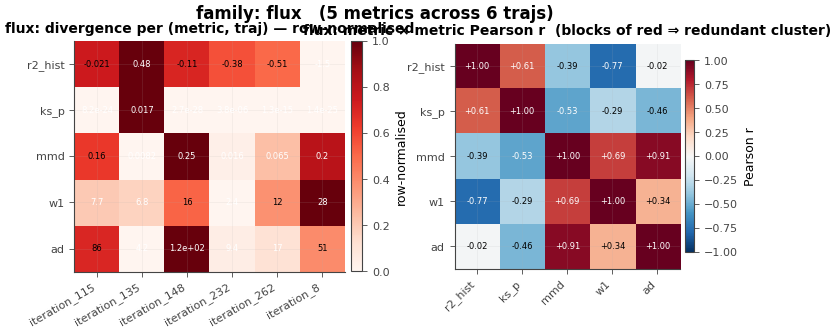

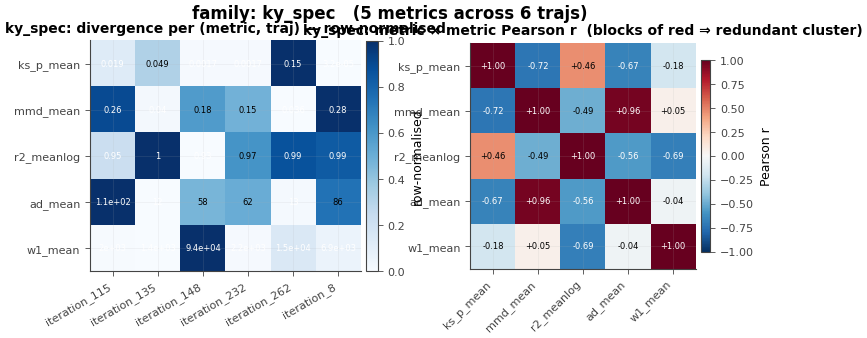

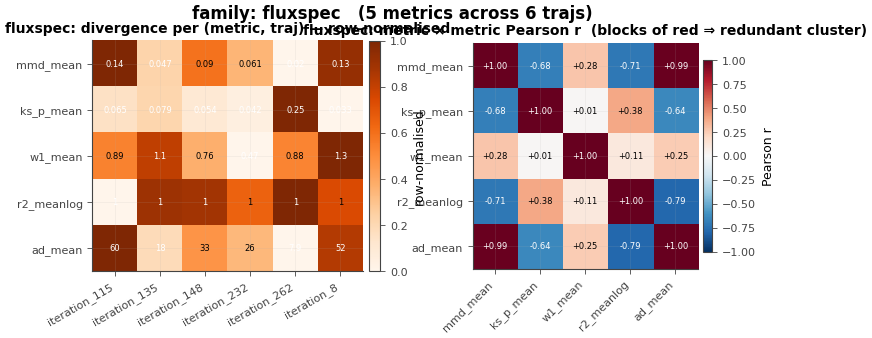

In [4]:
PRUNE_STD_THRESHOLD = 1e-4

M_full = divergence_pivot.drop(columns=[c for c in ("mean", "median", "std")
                                          if c in divergence_pivot.columns])
all_metrics = list(M_full.index)
traj_names  = list(M_full.columns)

FAMILIES    = ("flux", "ky_spec", "fluxspec")
FAMILY_CMAP = {
    "flux":     "Reds",
    "ky_spec":  "Blues",
    "fluxspec": "Oranges",
}
INTRA_CMAP = "RdBu_r"

def _family(m):
    for f in FAMILIES:
        if m.startswith(f + "_"): return f
    return "other"

def _type(m, f):
    return m[len(f) + 1:] if m.startswith(f + "_") else m

# ---- prune NaN / near-constant metrics across trajs --------------------
kept, pruned = [], []
for m in all_metrics:
    v = M_full.loc[m].to_numpy(dtype=float)
    finite = v[np.isfinite(v)]
    if finite.size < 2:
        pruned.append((m, "few finite")); continue
    if finite.std() <= PRUNE_STD_THRESHOLD * (abs(finite.mean()) + 1e-30):
        pruned.append((m, f"near-constant std={finite.std():.2e}")); continue
    kept.append(m)
if pruned:
    print(f"pruned {len(pruned)}/{len(all_metrics)} metrics:")
    for m, reason in pruned[:30]:
        print(f"  - {m}: {reason}")
    if len(pruned) > 30:
        print(f"  … and {len(pruned) - 30} more")

# ---- group ---------------------------------------------------------------
families_metrics = {f: [m for m in kept if _family(m) == f] for f in FAMILIES}
families_metrics = {f: ms for f, ms in families_metrics.items() if ms}

# ---- per-family figure: (left) metric × traj heatmap (row-normalised),
#                         (right) metric × metric Pearson r (cluster spotting)
for fam, ms in families_metrics.items():
    cmap_traj = FAMILY_CMAP.get(fam, "Greys")
    short = [_type(m, fam) for m in ms]

    # Panel 1: metric × traj, row-normalised so each metric is comparable.
    M = M_full.loc[ms].to_numpy(dtype=float)
    M_norm = np.zeros_like(M)
    for i in range(M.shape[0]):
        finite = M[i][np.isfinite(M[i])]
        if finite.size == 0:
            continue
        lo, hi = finite.min(), finite.max()
        rng = max(hi - lo, 1e-12)
        M_norm[i, :] = (M[i, :] - lo) / rng

    # Panel 2: intra-family metric × metric Pearson r across trajs.
    K = len(ms)
    R = np.full((K, K), np.nan)
    for i in range(K):
        for j in range(K):
            xi = M[i]; xj = M[j]
            mask = np.isfinite(xi) & np.isfinite(xj)
            if mask.sum() < 3 or np.std(xi[mask]) == 0 or np.std(xj[mask]) == 0:
                continue
            R[i, j] = float(np.corrcoef(xi[mask], xj[mask])[0, 1])

    fig, axes = plt.subplots(
        1, 2,
        figsize=(max(8, 0.45 * (len(traj_names) + K)), max(3, 0.34 * K)),
        gridspec_kw={"width_ratios": [max(1, len(traj_names)), max(1, K)],
                     "wspace": 0.35},
    )

    # left: metric × traj
    im0 = axes[0].imshow(M_norm, cmap=cmap_traj, aspect="auto", vmin=0, vmax=1)
    axes[0].set_yticks(range(K)); axes[0].set_yticklabels(short, fontsize=8)
    axes[0].set_xticks(range(len(traj_names)))
    axes[0].set_xticklabels([str(t) for t in traj_names], rotation=30, ha="right", fontsize=8)
    for i in range(K):
        for j in range(len(traj_names)):
            v = M[i, j]
            if np.isfinite(v):
                axes[0].text(j, i, f"{v:.2g}", ha="center", va="center",
                             fontsize=6,
                             color="black" if 0.25 < M_norm[i, j] < 0.75 else "white")
    axes[0].set_title(f"{fam}: divergence per (metric, traj) — row-normalised",
                       fontsize=10, fontweight="bold")
    plt.colorbar(im0, ax=axes[0], fraction=0.04, pad=0.02, label="row-normalised")

    # right: metric × metric Pearson r
    im1 = axes[1].imshow(R, cmap=INTRA_CMAP, aspect="equal", vmin=-1, vmax=1)
    axes[1].set_xticks(range(K)); axes[1].set_xticklabels(short, rotation=45, ha="right", fontsize=8)
    axes[1].set_yticks(range(K)); axes[1].set_yticklabels(short, fontsize=8)
    for i in range(K):
        for j in range(K):
            v = R[i, j]
            if np.isfinite(v):
                axes[1].text(j, i, f"{v:+.2f}", ha="center", va="center",
                             fontsize=6,
                             color="white" if abs(v) > 0.5 else "black")
    axes[1].set_title(f"{fam}: metric × metric Pearson r  "
                       "(blocks of red ⇒ redundant cluster)",
                       fontsize=10, fontweight="bold")
    plt.colorbar(im1, ax=axes[1], fraction=0.04, pad=0.02, label="Pearson r")

    fig.suptitle(f"family: {fam}   ({K} metrics across {len(traj_names)} trajs)",
                 fontsize=12, fontweight="bold", y=1.0)
    fig.tight_layout()

if gs_fid_per_source:
    print("\nGlobal GyroSwin FID per source (constant across trajs):")
    for src, v in gs_fid_per_source.items():
        print(f"  {src:20s}  FID = {v:.4f}")


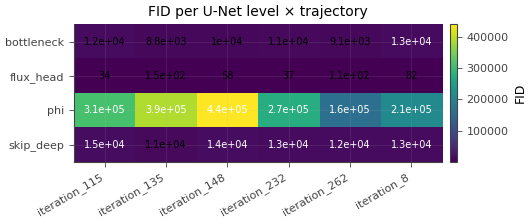

=== flux_rmse_meant per traj ===
iteration_115   11.6254
iteration_135   14.8144
iteration_148   21.9997
iteration_232    8.9872
iteration_262   37.9169
iteration_8     45.4924

=== values per (traj × {level, flux_rmse_meant}) ===
               bottleneck  flux_head         phi  skip_deep  flux_rmse_meant
iteration_115  12234.2822    34.2450 311616.3491 14895.1155          11.6254
iteration_135   8774.8818   145.2399 388071.1184 10506.7257          14.8144
iteration_148  10159.7165    58.2179 440346.6720 14121.2500          21.9997
iteration_232  11328.2957    37.2362 274445.4489 12855.6873           8.9872
iteration_262   9129.0106   111.8334 161156.7813 12340.3086          37.9169
iteration_8    12811.4140    82.0986 211240.3654 12753.6371          45.4924

=== Cross-level Pearson r (FIDs + flux_rmse_meant) ===
                 bottleneck  flux_head    phi  skip_deep  flux_rmse_meant
bottleneck           +1.000     -0.705 -0.244     +0.601           +0.113
flux_head            -0.70

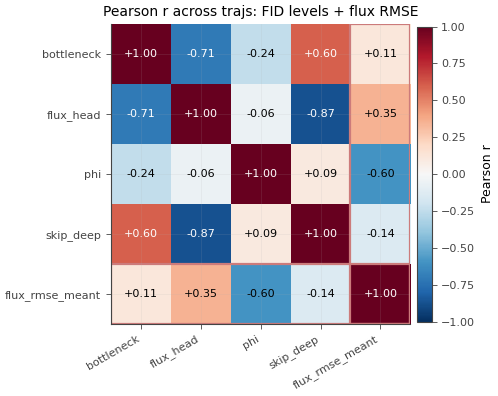

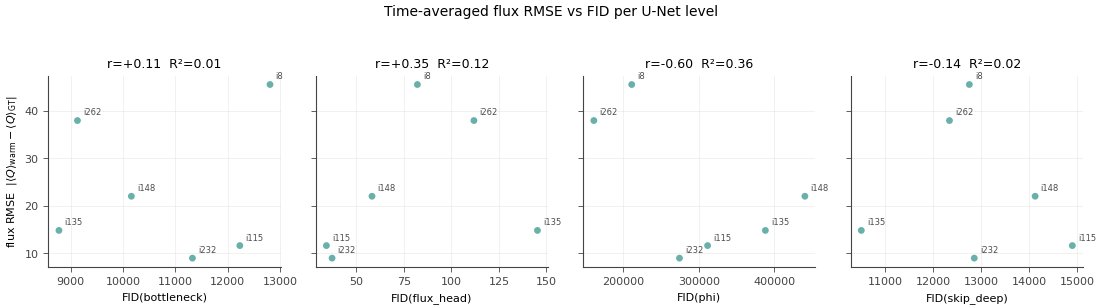

In [6]:
# === FID landscape: per-(level, traj) heatmap, level x level redundancy, ===
# === and time-averaged flux RMSE (physics baseline) folded in as a 5th    ===
# === row/column of the cross-correlation matrix.                          ===
import numpy as np
import pandas as pd

apply_paper_style()
per_iter_fids = globals().get("per_iter_fids", {})
warm_results  = globals().get("warm_results", {})
if not per_iter_fids:
    raise RuntimeError("run `latent_dashboard` first to populate per_iter_fids")


def _flux_rmse_meant(res):
    """Time-averaged warm flux vs time-averaged GT flux. Per-restart RMSE
    when the warm log carries `eflux_per_restart`; otherwise the absolute
    difference of the two means."""
    log_w = res.get("log_warm", {}) or {}
    ref = res.get("ref_flux_samples")
    if ref is None or len(np.asarray(ref).ravel()) == 0:
        return np.nan
    gt_mean = float(np.mean(np.asarray(ref, dtype=float)))
    if "eflux_per_restart" in log_w:
        e = np.asarray(log_w["eflux_per_restart"], dtype=float)
        T = e.shape[1]
        e_late = e[:, T // 2:]
        per_r = e_late.mean(axis=1)
        return float(np.sqrt(np.mean((per_r - gt_mean) ** 2)))
    if "eflux" in log_w:
        e = np.asarray(log_w["eflux"], dtype=float)
        warm_mean = float(e[len(e) // 2:].mean()) if e.size else np.nan
        return abs(warm_mean - gt_mean)
    return np.nan


trajs  = sorted(per_iter_fids.keys())
levels = sorted({lv for d in per_iter_fids.values() for lv in d})
M = np.array([[per_iter_fids[t].get(lv, np.nan) for t in trajs] for lv in levels],
              dtype=float)

# --- (a) per-(level, traj) heatmap ----------------------------------------
fig, ax = plt.subplots(figsize=(max(5.5, 0.55 * len(trajs)),
                                 max(2.4, 0.5 * len(levels))))
im = ax.imshow(M, cmap="viridis", aspect="auto")
ax.set_yticks(range(len(levels)));  ax.set_yticklabels(levels)
ax.set_xticks(range(len(trajs)));   ax.set_xticklabels(trajs, rotation=30, ha="right")
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M[i, j]
        if np.isfinite(v):
            ax.text(j, i, f"{v:.2g}", ha="center", va="center", fontsize=7,
                     color="white" if v > np.nanmedian(M) else "black")
ax.set_title("FID per U-Net level × trajectory", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label="FID")
fig.tight_layout()
save_fig(fig, "fid_heatmap_per_level_traj", RESULTS_DIR)
plt.show()

# --- (traj × {levels, flux_rmse_meant}) DataFrame -------------------------
fid_df = pd.DataFrame({lv: [per_iter_fids[t].get(lv, np.nan) for t in trajs]
                        for lv in levels}, index=trajs)
flux_rmse = pd.Series(
    [_flux_rmse_meant(warm_results.get(t, {})) for t in trajs],
    index=trajs, name="flux_rmse_meant",
)
print("=== flux_rmse_meant per traj ===")
print(flux_rmse.to_string(float_format=lambda x: f"{x:.4f}"))
fid_df_aug = pd.concat([fid_df, flux_rmse], axis=1)
print("\n=== values per (traj × {level, flux_rmse_meant}) ===")
print(fid_df_aug.to_string(float_format=lambda x: f"{x:.4f}"))

# Cross-correlation including the flux_rmse_meant row/column.
corr = fid_df_aug.corr(method="pearson")
print("\n=== Cross-level Pearson r (FIDs + flux_rmse_meant) ===")
print(corr.to_string(float_format=lambda x: f"{x:+.3f}"))

# --- (b) cross-level Pearson heatmap (5x5) --------------------------------
labels = list(fid_df_aug.columns)
fig, ax = plt.subplots(figsize=(0.7 * len(labels) + 1.5,
                                 0.7 * len(labels) + 1.0))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8,
                 color="white" if abs(v) > 0.6 else "black")
# highlight the flux_rmse_meant row+col (last index) with a darker frame
last = len(labels) - 1
ax.add_patch(plt.Rectangle((-0.5, last - 0.5), len(labels), 1,
                             fill=False, edgecolor=COLOR_FLUX, lw=1.6))
ax.add_patch(plt.Rectangle((last - 0.5, -0.5), 1, len(labels),
                             fill=False, edgecolor=COLOR_FLUX, lw=1.6))
ax.set_title("Pearson r across trajs: FID levels + flux RMSE", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Pearson r")
fig.tight_layout()
save_fig(fig, "fid_cross_level_corr", RESULTS_DIR)
plt.show()

# --- (c) per-level scatter: flux RMSE (physics baseline) vs FID -----------
fr = flux_rmse.to_numpy(dtype=float)
fig2, axes2 = plt.subplots(1, len(levels),
                            figsize=(2.8 * len(levels), 3.0),
                            sharey=True, squeeze=False)
for ax2, lv in zip(axes2[0], levels):
    f_v = fid_df[lv].to_numpy(dtype=float)
    mask = np.isfinite(f_v) & np.isfinite(fr)
    if mask.sum() >= 3 and np.std(f_v[mask]) > 0 and np.std(fr[mask]) > 0:
        r = float(np.corrcoef(f_v[mask], fr[mask])[0, 1])
        r2 = r ** 2
    else:
        r = np.nan; r2 = np.nan
    ax2.scatter(f_v[mask], fr[mask], s=24, color=COLOR_GYROFLOW,
                  edgecolor="none", alpha=0.9)
    for j, t in enumerate(fid_df.index):
        if mask[j]:
            ax2.annotate(t.replace("iteration_", "i"),
                          (f_v[j], fr[j]),
                          textcoords="offset points", xytext=(4, 4),
                          fontsize=6, color=COLOR_REF, alpha=0.8)
    ax2.set_xlabel(f"FID({lv})", fontsize=8)
    ax2.set_title(f"r={r:+.2f}  R²={r2:.2f}" if np.isfinite(r) else "n/a",
                    fontsize=9)
    ax2.grid(alpha=0.25)
axes2[0, 0].set_ylabel(r"flux RMSE  $|\langle Q\rangle_\mathrm{warm}-\langle Q\rangle_\mathrm{GT}|$",
                         fontsize=8)
fig2.suptitle("Time-averaged flux RMSE vs FID per U-Net level",
                fontsize=10, y=1.04)
fig2.tight_layout()
save_fig(fig2, "fluxrmse_vs_fid_per_level", RESULTS_DIR)
plt.show()

# Persist for the cross-method comparison notebook.
PAPER_FID_LANDSCAPE = {
    "fid_per_level_traj":    fid_df.to_dict(),
    "flux_rmse_meant":       flux_rmse.to_dict(),
    "fid_cross_level_corr":  corr.to_dict(),
}



=== sorted by family, then by max |r| across 4 FID levels ===
                        FID_skip_deep  FID_bottleneck  FID_flux_head  FID_phi    family
flux_ad                        +0.804          +0.338         -0.530   +0.478      flux
flux_ks_p                      -0.776          -0.582         +0.748   +0.420      flux
flux_mmd                       +0.691          +0.483         -0.413   +0.218      flux
flux_r2_hist                   -0.156          -0.625         +0.191   +0.674      flux
flux_rmse_meant                -0.135          +0.113         +0.345   -0.596      flux
flux_w1                        +0.091          +0.389         +0.114   -0.252      flux
flux_arima_l2                     NaN             NaN            NaN      NaN      flux
ky_spec_mmd_mean               +0.700          +0.950         -0.704   -0.006   ky_spec
ky_spec_ad_mean                +0.795          +0.929         -0.809   +0.009   ky_spec
ky_spec_r2_meanlog             -0.871          -0.287    

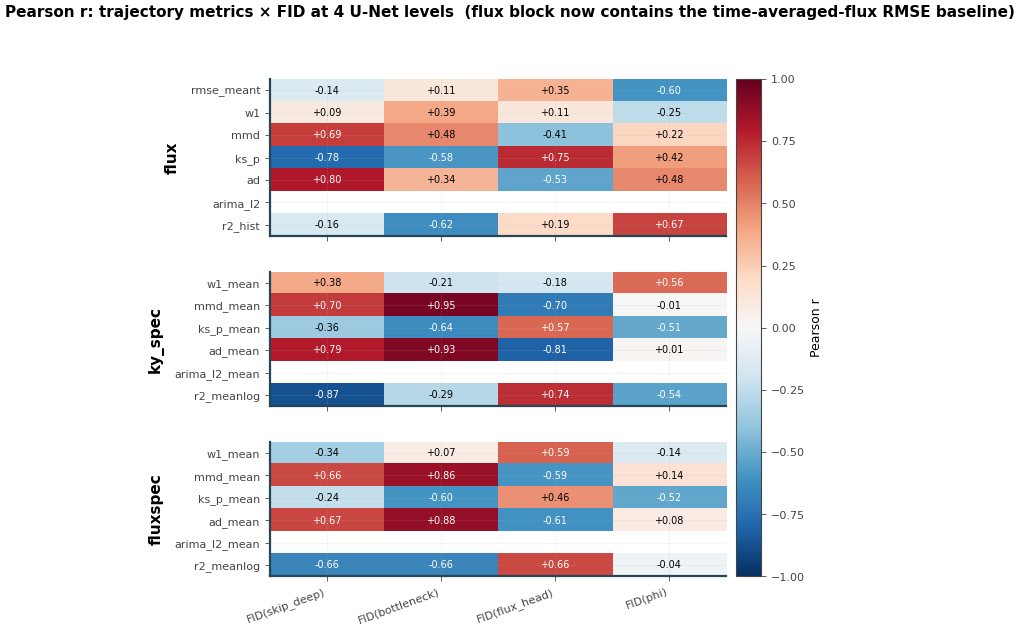

In [7]:
# === 18 trajectory metrics + flux RMSE  ×  FID at 4 U-Net levels ==========
# Pearson r heatmap of the divergence/RMSE metrics vs per-(traj, level) FID.
# `flux_rmse_meant` is added as a physics-baseline alongside the
# distributional families: time-averaged warm flux per restart compared to
# the time-averaged GT flux (per fluxes.dat tail). With R restarts:
#   flux_rmse_meant = sqrt( mean_r (<Q>_warm,r - <Q>_GT)^2 )
# Reduces to |<Q>_warm - <Q>_GT| if there is only one restart.
import numpy as np
import pandas as pd

_ns = globals()
_pif = _ns.get("per_iter_fids")
_warm = _ns.get("warm_results", {})
if not _pif:
    raise RuntimeError("per_iter_fids is empty or undefined — run the "
                        "`latent_dashboard` cell first.")
per_iter_fids = _pif


def _flux_rmse_meant(res):
    """RMSE of the time-averaged warm flux against the time-averaged GT flux.
    Uses per-restart traces when available so the RMSE has > 1 sample."""
    log_w = res.get("log_warm", {}) or {}
    ref = res.get("ref_flux_samples")
    if ref is None or len(np.asarray(ref).ravel()) == 0:
        return np.nan
    gt_mean = float(np.mean(np.asarray(ref, dtype=float)))
    if "eflux_per_restart" in log_w:
        e = np.asarray(log_w["eflux_per_restart"], dtype=float)  # (R, T)
        T = e.shape[1]
        e_late = e[:, T // 2:]                                    # post-sat half
        per_r_mean = e_late.mean(axis=1)                          # (R,)
        diffs = per_r_mean - gt_mean
        return float(np.sqrt(np.mean(diffs ** 2)))
    if "eflux" in log_w:
        e = np.asarray(log_w["eflux"], dtype=float)
        warm_mean = float(e[len(e) // 2:].mean()) if e.size else np.nan
        return abs(warm_mean - gt_mean)
    return np.nan


# Build per-traj table of metrics + FIDs.
rows = []
for traj, fids in per_iter_fids.items():
    if traj not in warm_results or not warm_results[traj].get("div_warm"):
        continue
    row = {"traj": traj, "split": warm_results[traj].get("split", "ID")}
    for lv, v in fids.items():
        row[f"FID_{lv}"] = v
    for k, v in warm_results[traj]["div_warm"].items():
        if k.endswith("_error") or k.endswith("_per_restart") or \
           k.endswith("_per_restart_mean") or k.endswith("_per_restart_std"):
            continue
        if not isinstance(v, (int, float)):
            continue
        row[k] = v
    # Physics baseline: time-averaged flux RMSE.
    row["flux_rmse_meant"] = _flux_rmse_meant(warm_results[traj])
    rows.append(row)

if len(rows) < 3:
    print(f"only {len(rows)} trajs with both FID + divergences — Pearson r needs >= 3")
else:
    corr_df = pd.DataFrame(rows)
    fid_cols = [c for c in corr_df.columns if c.startswith("FID_")]
    raw_metric_cols = [c for c in corr_df.columns
                       if c not in (["traj", "split"] + fid_cols)]

    FAMILY_ORDER = ("flux", "ky_spec", "fluxspec", "other")
    TYPE_ORDER   = ("rmse_meant",
                    "w1", "w1_mean", "mmd", "mmd_mean",
                    "ks_p", "ks_p_mean",
                    "ad", "ad_mean",
                    "arima_l2", "arima_l2_mean",
                    "r2_hist", "r2_meanlog")

    def _family(name):
        if name.startswith("flux_"):     return "flux"
        if name.startswith("ky_spec_"):  return "ky_spec"
        if name.startswith("fluxspec_"): return "fluxspec"
        return "other"
    def _type(name, fam):
        if fam == "flux":     return name[len("flux_"):]
        if fam == "ky_spec":  return name[len("ky_spec_"):]
        if fam == "fluxspec": return name[len("fluxspec_"):]
        return name
    def _sort_key(name):
        fam = _family(name); typ = _type(name, fam)
        fam_idx = FAMILY_ORDER.index(fam) if fam in FAMILY_ORDER else len(FAMILY_ORDER)
        typ_idx = TYPE_ORDER.index(typ) if typ in TYPE_ORDER else len(TYPE_ORDER) + hash(typ) % 1000
        return (fam_idx, typ_idx, name)

    metric_cols = sorted(raw_metric_cols, key=_sort_key)
    metric_families = [_family(m) for m in metric_cols]
    fam_label_pos = {}
    for fam in FAMILY_ORDER:
        idxs = [i for i, f in enumerate(metric_families) if f == fam]
        if idxs:
            fam_label_pos[fam] = (idxs[0], idxs[-1])

    corr_matrix = pd.DataFrame(index=metric_cols, columns=fid_cols, dtype=float)
    for m in metric_cols:
        for fcol in fid_cols:
            x = corr_df[m].to_numpy(dtype=float)
            y = corr_df[fcol].to_numpy(dtype=float)
            mask = np.isfinite(x) & np.isfinite(y)
            if mask.sum() < 3 or np.std(x[mask]) == 0 or np.std(y[mask]) == 0:
                corr_matrix.loc[m, fcol] = np.nan
            else:
                corr_matrix.loc[m, fcol] = float(np.corrcoef(x[mask], y[mask])[0, 1])

    families_present = [fam for fam in FAMILY_ORDER if fam in fam_label_pos]
    height_ratios = [(fam_label_pos[f][1] - fam_label_pos[f][0] + 1)
                     for f in families_present]
    fig, axes = plt.subplots(
        len(families_present), 1, sharex=True,
        figsize=(max(6, 1.6 * len(fid_cols)), max(4, 0.34 * len(metric_cols))),
        gridspec_kw={"height_ratios": height_ratios, "hspace": 0.25},
    )
    if len(families_present) == 1:
        axes = [axes]
    for ax_i, fam in zip(axes, families_present):
        lo, hi = fam_label_pos[fam]
        block_metrics = metric_cols[lo:hi + 1]
        block_short = [_type(m, fam) for m in block_metrics]
        Mb = corr_matrix.loc[block_metrics].to_numpy(dtype=float)
        im = ax_i.imshow(Mb, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
        ax_i.set_yticks(range(len(block_short)))
        ax_i.set_yticklabels(block_short, fontsize=8)
        ax_i.set_xticks(range(len(fid_cols)))
        ax_i.set_xticklabels([c.replace("FID_", "FID(") + ")" for c in fid_cols],
                              rotation=20, ha="right", fontsize=8)
        for r in range(Mb.shape[0]):
            for c2 in range(Mb.shape[1]):
                v = Mb[r, c2]
                if np.isfinite(v):
                    ax_i.text(c2, r, f"{v:+.2f}", ha="center", va="center",
                              fontsize=7,
                              color="white" if abs(v) > 0.5 else "black")
        ax_i.set_ylabel(fam, fontsize=11, fontweight="bold", rotation=90, labelpad=8)
        for spine in ax_i.spines.values():
            spine.set_linewidth(1.6); spine.set_edgecolor("#264653")
    fig.suptitle(
        f"Pearson r: trajectory metrics × FID at {len(fid_cols)} U-Net levels  "
        f"(flux block now contains the time-averaged-flux RMSE baseline)",
        fontsize=11, fontweight="bold", y=0.995,
    )
    fig.colorbar(im, ax=axes, fraction=0.06, pad=0.02, label="Pearson r")

    # Leaderboard: rank within family by max |r| across all FID levels.
    print(f"\n=== sorted by family, then by max |r| across {len(fid_cols)} FID levels ===")
    lb = corr_matrix.copy()
    lb["family"] = [_family(m) for m in lb.index]
    lb["best_abs_r"] = lb[fid_cols].abs().max(axis=1)
    lb = lb.sort_values(
        ["family", "best_abs_r"], ascending=[True, False],
        key=lambda col: col.map({f: i for i, f in enumerate(FAMILY_ORDER)})
                          if col.name == "family" else col,
    ).drop(columns="best_abs_r")
    print(lb.to_string(float_format=lambda x: f"{x:+.3f}"))


In [8]:
R_REDUNDANT = 0.95   # |r| above which two metrics are considered redundant
TOP_N       = 12     # leaderboard length per target

if not warm_results:
    raise RuntimeError("warm_results is empty — run the warm-restart loop first.")

# Build the unified table: rows = traj, cols = targets + every divergence metric.
def _flux_rmse_proxy(res):
    """Relative RMSE between warm flux tail and GT-saturated tail. Independent
    proxy for "is the warm trajectory the right operating point?". Uses
    ref_flux_samples if available, else log_gt-tail."""
    lw = np.asarray(res["log_warm"]["eflux"])
    if lw.size == 0:
        return np.nan
    warm_tail = lw[-min(80, len(lw)):]
    ref = res.get("ref_flux_samples")
    if ref is None or len(ref) == 0:
        return np.nan
    ref = np.asarray(ref)
    return float(np.sqrt(np.mean((warm_tail.mean() - ref.mean()) ** 2 +
                                  (warm_tail.std() - ref.std()) ** 2))
                 / max(abs(ref.mean()), 1e-12))

rows = []
for traj, res in warm_results.items():
    if not res.get("div_warm"):
        continue
    row = {"traj": traj, "split": res.get("split", "ID")}
    if "per_iter_fids" in dir() and traj in per_iter_fids:
        for _lv, _v in per_iter_fids[traj].items():
            row[f"FID_{_lv}"] = _v
    row["flux_rmse"] = _flux_rmse_proxy(res)
    for k, v in res["div_warm"].items():
        if k.endswith("_error") or k.endswith("_per_restart") or \
           k.endswith("_per_restart_mean") or k.endswith("_per_restart_std"):
            continue
        if not isinstance(v, (int, float)):
            continue
        row[k] = v
    rows.append(row)

if len(rows) < 3:
    raise RuntimeError(f"only {len(rows)} trajs available — need ≥ 3 for Pearson r")

big_df = pd.DataFrame(rows)
print(f"Working with {len(big_df)} trajectories: "
      f"{(big_df['split']=='ID').sum()} ID + {(big_df['split']=='OOD').sum()} OOD\n")

target_cols = [c for c in big_df.columns
               if (c.startswith("FID_") or c == "flux_rmse")
                  and big_df[c].notna().sum() >= 3]
metric_cols = [c for c in big_df.columns
               if c not in (["traj", "split", "flux_rmse"] + target_cols)
                  and not c.startswith("FID_")
                  and big_df[c].notna().sum() >= 3
                  and big_df[c].std() > 1e-12 * (abs(big_df[c].mean()) + 1e-30)]
print(f"Targets:  {target_cols}")
print(f"Metrics:  {len(metric_cols)} (after pruning NaN / near-constant)\n")

def _pearson(x, y):
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3 or np.std(x[mask]) == 0 or np.std(y[mask]) == 0:
        return np.nan
    return float(np.corrcoef(x[mask], y[mask])[0, 1])

# (1) Leaderboards per target -------------------------------------------------
for tgt in target_cols:
    rs = [(m, _pearson(big_df[m], big_df[tgt])) for m in metric_cols]
    rs = [(m, r) for m, r in rs if np.isfinite(r)]
    rs.sort(key=lambda x: -abs(x[1]))
    print(f"=== top {TOP_N} metrics most correlated with {tgt} ===")
    for m, r in rs[:TOP_N]:
        print(f"  {r:+.3f}   {m}")
    print()

# (2) Cross-family redundancy clusters ----------------------------------------
# Pearson r matrix across all kept metrics (across families).
K = len(metric_cols)
R = np.full((K, K), np.nan)
for i in range(K):
    for j in range(K):
        R[i, j] = _pearson(big_df[metric_cols[i]], big_df[metric_cols[j]])

# Greedy clustering: each metric joins the first cluster whose centroid has
# |r| ≥ R_REDUNDANT with it; otherwise starts a new cluster.
clusters = []
for i, m in enumerate(metric_cols):
    placed = False
    for cl in clusters:
        # representative: first member
        rep_idx = cl[0]
        if np.isfinite(R[i, rep_idx]) and abs(R[i, rep_idx]) >= R_REDUNDANT:
            cl.append(i); placed = True; break
    if not placed:
        clusters.append([i])

# Sort clusters by size (largest first), then by max |r| with the FIDs.
def _cluster_key(cl):
    rep = metric_cols[cl[0]]
    rs = [abs(_pearson(big_df[rep], big_df[t])) for t in target_cols]
    rs = [r for r in rs if np.isfinite(r)]
    return (-len(cl), -(max(rs) if rs else 0.0))
clusters.sort(key=_cluster_key)

print(f"=== {len(clusters)} redundancy clusters at |r| ≥ {R_REDUNDANT} ===\n")
for ci, cl in enumerate(clusters):
    rep = metric_cols[cl[0]]
    rep_rs = {t: _pearson(big_df[rep], big_df[t]) for t in target_cols}
    rep_rs_str = "  ".join(
        f"r({t})={rep_rs[t]:+.2f}" for t in target_cols if np.isfinite(rep_rs[t])
    )
    print(f"cluster {ci:2d}  (n={len(cl)})  rep = {rep}")
    print(f"             {rep_rs_str}")
    if len(cl) > 1:
        print(f"             redundant: {[metric_cols[k] for k in cl[1:]]}")
    print()

print("=== recommended canonical set (one per cluster, sorted by best target |r|) ===")
canonical = []
for cl in clusters:
    rep = metric_cols[cl[0]]
    best_r = max(
        (abs(_pearson(big_df[rep], big_df[t])) for t in target_cols),
        default=0.0,
    )
    canonical.append((rep, best_r, len(cl)))
canonical.sort(key=lambda x: -x[1])
for rep, best_r, n_cluster in canonical:
    print(f"  best |r|={best_r:.3f}  (cluster size {n_cluster:>2})  {rep}")

print(f"\nIf {R_REDUNDANT} is too aggressive (everything ends up in one cluster) drop it to "
      f"0.85; if too lenient (every metric is its own cluster) raise it to 0.97.")


Working with 6 trajectories: 6 ID + 0 OOD

Targets:  ['FID_skip_deep', 'FID_bottleneck', 'FID_flux_head', 'FID_phi', 'flux_rmse']
Metrics:  15 (after pruning NaN / near-constant)

=== top 12 metrics most correlated with FID_skip_deep ===
  -0.871   ky_spec_r2_meanlog
  +0.804   flux_ad
  +0.795   ky_spec_ad_mean
  -0.776   flux_ks_p
  +0.700   ky_spec_mmd_mean
  +0.691   flux_mmd
  +0.668   fluxspec_ad_mean
  -0.662   fluxspec_r2_meanlog
  +0.661   fluxspec_mmd_mean
  +0.376   ky_spec_w1_mean
  -0.364   ky_spec_ks_p_mean
  -0.341   fluxspec_w1_mean

=== top 12 metrics most correlated with FID_bottleneck ===
  +0.950   ky_spec_mmd_mean
  +0.929   ky_spec_ad_mean
  +0.882   fluxspec_ad_mean
  +0.864   fluxspec_mmd_mean
  -0.661   fluxspec_r2_meanlog
  -0.636   ky_spec_ks_p_mean
  -0.625   flux_r2_hist
  -0.596   fluxspec_ks_p_mean
  -0.582   flux_ks_p
  +0.483   flux_mmd
  +0.389   flux_w1
  +0.338   flux_ad

=== top 12 metrics most correlated with FID_flux_head ===
  -0.809   ky_spec_ad

In [9]:
per_iter_fids = globals().get("per_iter_fids", {})
if not per_iter_fids:
    raise RuntimeError("run latent_dashboard cell first to populate per_iter_fids")
warm_results = globals().get("warm_results", {})
if not warm_results:
    raise RuntimeError("run cell 28 first to populate warm_results")

BASE_MEASURES = ["w1", "mmd", "ks_p", "ad", "arima_l2", "r2"]
FAMILIES      = ["flux", "ky_spec", "fluxspec"]

# What name does a (family, base) combo carry in warm_results[traj]["div_warm"]?
def _metric_name(family, base):
    if family == "flux":
        return f"flux_{base}_hist" if base == "r2" else f"flux_{base}"
    if family in ("ky_spec", "fluxspec"):
        return f"{family}_r2_meanlog" if base == "r2" else f"{family}_{base}_mean"
    return None

SEMANTICS = {
    "w1":       ("Wasserstein-1",         "physical units, transport cost",     "lower"),
    "mmd":      ("MMD-RBF²",              "smooth functional gap",                "lower"),
    "ks_p":     ("KS p-value",            "indistinguishability probability",    "higher"),
    "ad":       ("Anderson–Darling",      "tail-weighted shape disagreement",    "lower"),
    "arima_l2": ("ARIMA(2,0,2) param L2",  "dynamics / autocorrelation mismatch", "lower"),
    "r2":       ("R² (hist or meanlog)",  "point-wise reconstruction fidelity",  "higher"),
}

# Build a combined long DataFrame: one row per (traj, fid_level), wide cols per metric
rows = []
for traj, fids in per_iter_fids.items():
    if traj not in warm_results or not warm_results[traj].get("div_warm"):
        continue
    div = warm_results[traj]["div_warm"]
    for fid_lv, fid_v in fids.items():
        row = {"traj": traj, "fid_level": fid_lv, "FID": fid_v,
               "split": warm_results[traj].get("split", "ID")}
        for fam in FAMILIES:
            for base in BASE_MEASURES:
                key = _metric_name(fam, base)
                row[f"{fam}__{base}"] = div.get(key, np.nan)
        rows.append(row)

if not rows:
    raise RuntimeError("no overlap between per_iter_fids and warm_results[*]['div_warm']")

big = pd.DataFrame(rows)
fid_levels = sorted(big["fid_level"].unique())
print(f"Aggregating across {len(big['traj'].unique())} trajs × {len(fid_levels)} FID levels = "
      f"{len(big)} (traj, level) pairs.")

# Per (family, base, fid_level): Pearson r between the metric and FID across trajs.
def _pearson_safe(df, x_col, y_col):
    x = df[x_col].to_numpy(dtype=float); y = df[y_col].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3 or np.std(x[mask]) == 0 or np.std(y[mask]) == 0:
        return np.nan
    return float(np.corrcoef(x[mask], y[mask])[0, 1])

corr_cube = {}  # corr_cube[base][family][fid_level] = r
for base in BASE_MEASURES:
    corr_cube[base] = {}
    for fam in FAMILIES:
        corr_cube[base][fam] = {}
        col = f"{fam}__{base}"
        for fid_lv in fid_levels:
            sub = big[big["fid_level"] == fid_lv]
            corr_cube[base][fam][fid_lv] = _pearson_safe(sub, col, "FID")

# Score each base.
print(f"\n{'base':>10s}  {'mean|r|':>8s}  {'min|r|':>8s}  {'coverage':>8s}  "
      f"{'sign-consistent':>15s}  semantics")
print(f"{'-'*10}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*15}  {'-'*40}")
ranked = []
for base in BASE_MEASURES:
    rs = []
    fam_max_abs = {}
    for fam in FAMILIES:
        per_fid = [corr_cube[base][fam][lv] for lv in fid_levels]
        finite = [r for r in per_fid if np.isfinite(r)]
        if finite:
            rs.extend(finite)
            fam_max_abs[fam] = max(abs(r) for r in finite)
    if not rs:
        continue
    abs_rs = [abs(r) for r in rs]
    mean_abs = float(np.mean(abs_rs))
    min_abs_per_fam = min(fam_max_abs.values()) if fam_max_abs else 0.0
    coverage = sum(1 for v in fam_max_abs.values() if v >= 0.5)
    # sign consistency: do the family-best correlations all have the same sign?
    fam_best_signed = {}
    for fam in FAMILIES:
        per_fid = [corr_cube[base][fam][lv] for lv in fid_levels]
        finite = [(abs(r), r) for r in per_fid if np.isfinite(r)]
        if finite:
            finite.sort(reverse=True)
            fam_best_signed[fam] = finite[0][1]
    signs = {1 if v > 0 else -1 for v in fam_best_signed.values() if abs(v) >= 0.3}
    sign_consistent = "yes" if len(signs) <= 1 else "no"

    ranked.append({
        "base": base, "mean_abs": mean_abs, "min_per_fam_abs": min_abs_per_fam,
        "coverage": coverage, "sign_consistent": sign_consistent,
        "fam_best_signed": fam_best_signed,
    })

ranked.sort(key=lambda d: (-d["coverage"], -d["mean_abs"], -d["min_per_fam_abs"]))
for d in ranked:
    label, descr, dirn = SEMANTICS[d["base"]]
    print(f"{d['base']:>10s}  {d['mean_abs']:>8.3f}  {d['min_per_fam_abs']:>8.3f}  "
          f"{d['coverage']:>5d}/3  {d['sign_consistent']:>15s}  "
          f"{label:14s}  ({descr})")

# Per-base, per-family, per-fid-level table for the top recommendation.
print("\n=== top recommendation: detailed (family × FID-level) Pearson r ===")
top = ranked[0]["base"]
label, descr, dirn = SEMANTICS[top]
print(f"\n  best base measure : {top}  ({label}, {descr}; {dirn} = better)\n")
header = f"  {'family':>10s}  " + "  ".join(f"{lv:>14s}" for lv in fid_levels)
print(header)
for fam in FAMILIES:
    row = corr_cube[top][fam]
    cells = "  ".join(
        (f"{row[lv]:>+14.3f}" if np.isfinite(row[lv]) else f"{'nan':>14s}")
        for lv in fid_levels
    )
    print(f"  {fam:>10s}  {cells}")

print(f"\nIn the paper, report {top} consistently as flux_{top}{'_hist' if top=='r2' else ''} / "
      f"ky_spec_{top}{'_meanlog' if top=='r2' else '_mean'} / fluxspec_{top}"
      f"{'_meanlog' if top=='r2' else '_mean'} alongside the FID columns. ")
print(f"Direction: {dirn} = better warm-start. ")
if ranked[0]["sign_consistent"] != "yes":
    print("WARNING: sign of correlation is not consistent across families — flag this in caption.")

Aggregating across 6 trajs × 4 FID levels = 24 (traj, level) pairs.

      base   mean|r|    min|r|  coverage  sign-consistent  semantics
----------  --------  --------  --------  ---------------  ----------------------------------------
        ad     0.578     0.804      3/3              yes  Anderson–Darling  (tail-weighted shape disagreement)
       mmd     0.535     0.691      3/3              yes  MMD-RBF²        (smooth functional gap)
      ks_p     0.535     0.596      3/3              yes  KS p-value      (indistinguishability probability)
        r2     0.509     0.663      3/3               no  R² (hist or meanlog)  (point-wise reconstruction fidelity)
        w1     0.277     0.389      2/3              yes  Wasserstein-1   (physical units, transport cost)

=== top recommendation: detailed (family × FID-level) Pearson r ===

  best base measure : ad  (Anderson–Darling, tail-weighted shape disagreement; lower = better)

      family      bottleneck       flux_head          

In [10]:
# === alternative correlation measures (Pearson is not the only knob) =======
# For each (family, base measure) cell of the warm-vs-FID grid we report
# Pearson, Spearman, Kendall, R² (=Pearson² with sign), and a 95% bootstrap
# CI on Pearson. With N=6 trajs the bootstrap CI usually crosses zero —
# strong correlations are then statistical artefacts, not a structural fact.
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, kendalltau

per_iter_fids = globals().get("per_iter_fids", {})
warm_results  = globals().get("warm_results", {})
if not per_iter_fids:
    raise RuntimeError("run latent_dashboard first")

BASE_MEASURES = ["w1", "mmd", "ks_p", "ad", "arima_l2", "r2"]
FAMILIES      = ["flux", "ky_spec", "fluxspec"]
LEVELS        = sorted({lv for d in per_iter_fids.values() for lv in d})


def _metric_name(family, base):
    if family == "flux":
        return f"flux_{base}_hist" if base == "r2" else f"flux_{base}"
    return f"{family}_r2_meanlog" if base == "r2" else f"{family}_{base}_mean"


def _bootstrap_pearson_ci(x, y, n_boot=2000, alpha=0.05, rng=None):
    rng = rng or np.random.default_rng(0)
    n = len(x)
    if n < 4:
        return (np.nan, np.nan)
    idx = rng.integers(0, n, (n_boot, n))
    rs = np.full(n_boot, np.nan)
    for b in range(n_boot):
        xb, yb = x[idx[b]], y[idx[b]]
        if np.std(xb) == 0 or np.std(yb) == 0:
            continue
        rs[b] = np.corrcoef(xb, yb)[0, 1]
    rs = rs[np.isfinite(rs)]
    if rs.size == 0:
        return (np.nan, np.nan)
    return float(np.quantile(rs, alpha / 2)), float(np.quantile(rs, 1 - alpha / 2))


trajs = [t for t in per_iter_fids if t in warm_results
          and warm_results[t].get("div_warm")]

rows = []
for fam in FAMILIES:
    for base in BASE_MEASURES:
        mname = _metric_name(fam, base)
        m = np.array([warm_results[t]["div_warm"].get(mname, np.nan) for t in trajs], float)
        for lv in LEVELS:
            f = np.array([per_iter_fids[t].get(lv, np.nan) for t in trajs], float)
            mask = np.isfinite(m) & np.isfinite(f)
            if mask.sum() < 4 or np.std(m[mask]) == 0 or np.std(f[mask]) == 0:
                rows.append({"family": fam, "base": base, "level": lv,
                              "pearson": np.nan, "spearman": np.nan,
                              "kendall": np.nan, "r2": np.nan,
                              "ci_lo": np.nan, "ci_hi": np.nan})
                continue
            p = float(np.corrcoef(m[mask], f[mask])[0, 1])
            s = float(spearmanr(m[mask], f[mask]).correlation)
            k = float(kendalltau(m[mask], f[mask]).correlation)
            ci_lo, ci_hi = _bootstrap_pearson_ci(m[mask], f[mask])
            rows.append({"family": fam, "base": base, "level": lv,
                          "pearson": p, "spearman": s, "kendall": k,
                          "r2": p ** 2 * (1 if p >= 0 else -1),
                          "ci_lo": ci_lo, "ci_hi": ci_hi})

corr_df = pd.DataFrame(rows)
print("=== correlation measures per (family, base, level) ===")
print(corr_df.to_string(index=False, float_format=lambda x: f"{x:+.2f}"))

# Headline: per (family, base) take the level with max |Pearson|, alongside
# Spearman/Kendall and CI, sorted by |Spearman|.
def _best(group):
    g = group.dropna(subset=["pearson"])
    if g.empty:
        return None
    i = g["pearson"].abs().idxmax()
    return g.loc[i]

best_rows = (corr_df.groupby(["family", "base"], group_keys=False)
                     .apply(_best)
                     .dropna()
                     .sort_values(by="spearman", key=lambda s: s.abs(), ascending=False))
print("\n=== best level per (family, base) — ranked by |Spearman| ===")
print(best_rows.to_string(index=False, float_format=lambda x: f"{x:+.2f}"))

# Cross-level FID×FID matrix with the same alternatives.
print("\n=== Cross-level FID × FID — alternative measures ===")
fid_df = pd.DataFrame({lv: [per_iter_fids[t].get(lv, np.nan) for t in trajs]
                       for lv in LEVELS}, index=trajs)
for name, fn in (("Pearson", lambda a, b: float(np.corrcoef(a, b)[0, 1])),
                 ("Spearman", lambda a, b: float(spearmanr(a, b).correlation)),
                 ("Kendall",  lambda a, b: float(kendalltau(a, b).correlation))):
    out = pd.DataFrame(np.eye(len(LEVELS)), index=LEVELS, columns=LEVELS)
    for i, li in enumerate(LEVELS):
        for j, lj in enumerate(LEVELS):
            a = fid_df[li].to_numpy(float); b = fid_df[lj].to_numpy(float)
            mask = np.isfinite(a) & np.isfinite(b)
            if mask.sum() < 3 or np.std(a[mask]) == 0 or np.std(b[mask]) == 0:
                out.iloc[i, j] = np.nan
            else:
                out.iloc[i, j] = fn(a[mask], b[mask])
    print(f"\n  {name}:")
    print(out.to_string(float_format=lambda x: f"{x:+.2f}"))


=== correlation measures per (family, base, level) ===
  family     base      level  pearson  spearman  kendall    r2  ci_lo  ci_hi
    flux       w1 bottleneck    +0.39     +0.37    +0.33 +0.15  -0.75  +1.00
    flux       w1  flux_head    +0.11     +0.14    +0.07 +0.01  -0.94  +0.99
    flux       w1        phi    -0.25     -0.14    -0.07 -0.06  -0.94  +0.95
    flux       w1  skip_deep    +0.09     +0.09    +0.07 +0.01  -0.68  +0.81
    flux      mmd bottleneck    +0.48     +0.54    +0.47 +0.23  -0.40  +1.00
    flux      mmd  flux_head    -0.41     -0.37    -0.33 -0.17  -1.00  +0.71
    flux      mmd        phi    +0.22     +0.14    +0.07 +0.05  -0.90  +0.93
    flux      mmd  skip_deep    +0.69     +0.60    +0.47 +0.48  +0.14  +1.00
    flux     ks_p bottleneck    -0.58     -0.54    -0.47 -0.34  -0.99  +0.42
    flux     ks_p  flux_head    +0.75     +0.37    +0.33 +0.56  -0.85  +0.99
    flux     ks_p        phi    +0.42     -0.14    -0.07 +0.18  -0.80  +0.96
    flux     ks_p  sk

/tmp/ipykernel_2168095/1077434617.py:84: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_best)


saved: {'pdf': PosixPath('/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/figs/paper/metric_vs_fid_ad.pdf'), 'png': PosixPath('/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/figs/paper/metric_vs_fid_ad.png')}


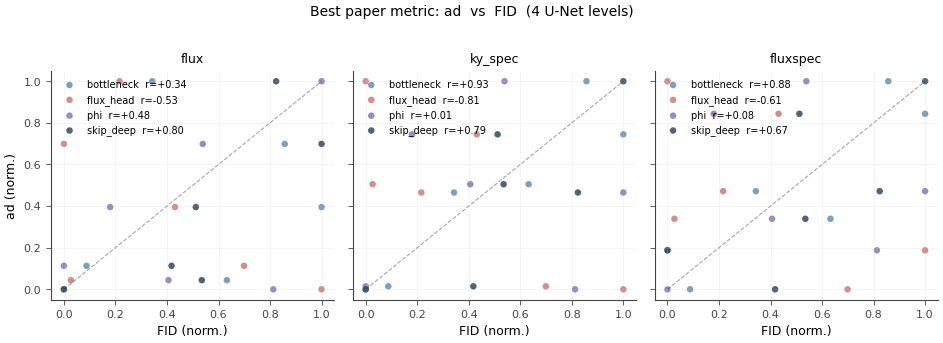

In [11]:
import numpy as np

apply_paper_style()
TOP_BASE = ranked[0]["base"]
LEVEL_COLOR = {
    "skip_deep":  darken(COLOR_QY, 0.5),
    "bottleneck": COLOR_QY,
    "flux_head":  COLOR_FLUX,
    "phi":        COLOR_KY,
}
fams = ["flux", "ky_spec", "fluxspec"]


def _norm01(a):
    a = np.asarray(a, dtype=float)
    f = a[np.isfinite(a)]
    if f.size == 0 or f.max() == f.min():
        return np.zeros_like(a)
    return (a - f.min()) / (f.max() - f.min())


fig, axes = plt.subplots(1, len(fams), figsize=(3.2 * len(fams), 3.4),
                          sharex=True, sharey=True)
PAPER_METRIC_DATA = {"top_base": TOP_BASE, "fid_levels": list(fid_levels),
                     "panels": {}}

for col, fam in enumerate(fams):
    ax = axes[col]
    panel = {"per_level": {}}
    metric_col = f"{fam}__{TOP_BASE}"
    metric_vals = big[metric_col].to_numpy(dtype=float)
    for lv in fid_levels:
        sub = big[big["fid_level"] == lv]
        m = sub[metric_col].to_numpy(dtype=float)
        f = sub["FID"].to_numpy(dtype=float)
        ok = np.isfinite(m) & np.isfinite(f)
        if ok.sum() < 2:
            continue
        x = _norm01(f[ok])
        y = _norm01(m[ok])
        r = corr_cube[TOP_BASE][fam][lv]
        c = LEVEL_COLOR.get(lv, "#666")
        ax.scatter(x, y, s=22, color=c, edgecolor="none", alpha=0.85,
                    label=f"{lv}  r={r:+.2f}" if np.isfinite(r) else lv)
        panel["per_level"][lv] = {"fid_norm": x, "metric_norm": y,
                                   "fid_raw": f[ok], "metric_raw": m[ok], "r": r}
    ax.plot([0, 1], [0, 1], color=COLOR_REF, lw=0.8, ls="--", alpha=0.4)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(fam, fontsize=9)
    if col == 0:
        ax.set_ylabel(f"{TOP_BASE} (norm.)")
    ax.set_xlabel("FID (norm.)")
    ax.legend(fontsize=7, loc="upper left", frameon=False)
    PAPER_METRIC_DATA["panels"][fam] = panel

fig.suptitle(f"Best paper metric: {TOP_BASE}  vs  FID  (4 U-Net levels)",
              fontsize=10, y=1.02)
fig.tight_layout()
paths = save_fig(fig, f"metric_vs_fid_{TOP_BASE}", RESULTS_DIR)
print(f"saved: {paths}")
plt.show()

In [12]:
import pandas as pd
import numpy as np

# 4-level FID per trajectory
fid_rows = []
for traj, fids in per_iter_fids.items():
    row = {"traj": traj, "split": warm_results.get(traj, {}).get("split", "ID")}
    row.update(fids)
    fid_rows.append(row)
fid_df = pd.DataFrame(fid_rows).set_index("traj").sort_index()
print("=== FIDs at 4 U-Net levels per trajectory ===")
print(fid_df.to_string(float_format=lambda x: f"{x:.4f}"))

# Per-traj distributional metrics (warm vs GT) for the canonical 6 base measures
METRIC_KEYS = {
    "flux":     {"mmd": "flux_mmd",          "ad": "flux_ad",          "ks_p": "flux_ks_p",
                  "w1": "flux_w1",            "arima_l2": "flux_arima_l2",
                  "r2": "flux_r2_hist"},
    "ky_spec":  {"mmd": "ky_spec_mmd_mean",  "ad": "ky_spec_ad_mean",  "ks_p": "ky_spec_ks_p_mean",
                  "w1": "ky_spec_w1_mean",    "arima_l2": "ky_spec_arima_l2_mean",
                  "r2": "ky_spec_r2_meanlog"},
    "fluxspec": {"mmd": "fluxspec_mmd_mean", "ad": "fluxspec_ad_mean", "ks_p": "fluxspec_ks_p_mean",
                  "w1": "fluxspec_w1_mean",   "arima_l2": "fluxspec_arima_l2_mean",
                  "r2": "fluxspec_r2_meanlog"},
}

div_rows = []
for traj, res in warm_results.items():
    div = res.get("div_warm", {}) or {}
    row = {"traj": traj, "split": res.get("split", "ID")}
    for fam, kmap in METRIC_KEYS.items():
        for short, key in kmap.items():
            row[f"{fam}_{short}"] = div.get(key, np.nan)
    div_rows.append(row)
div_df = pd.DataFrame(div_rows).set_index("traj").sort_index()
print("\n=== distributional metrics (warm vs GT) ===")
print(div_df.to_string(float_format=lambda x: f"{x:.4g}"))

# Aggregated summary: mean over trajectories per (split, family, measure)
SUMMARY_MEASURES = ["mmd", "ad", "ks_p", "w1", "arima_l2", "r2"]
summary_rows = []
for split in ("ID", "OOD", "ALL"):
    sub = div_df if split == "ALL" else div_df[div_df["split"] == split]
    if sub.empty:
        continue
    row = {"split": split, "n": len(sub)}
    for fam in METRIC_KEYS:
        for m in SUMMARY_MEASURES:
            col = f"{fam}_{m}"
            if col in sub:
                row[f"{fam}_{m}"] = float(sub[col].mean(skipna=True))
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows).set_index("split")
print("\n=== summary (mean per split) ===")
print(summary_df.to_string(float_format=lambda x: f"{x:.4g}"))

# Also: FID summary per split.
fid_summary = (fid_df.reset_index()
                  .groupby("split")[list(per_iter_fids[next(iter(per_iter_fids))].keys())]
                  .mean())
print("\n=== FID summary (mean per split) ===")
print(fid_summary.to_string(float_format=lambda x: f"{x:.4f}"))

# Persist the raw per-traj tables (CSV for inspection, plus they go into the
# pickle dump in the next cell).
import os
os.makedirs(RESULTS_DIR, exist_ok=True)
fid_df.to_csv(os.path.join(RESULTS_DIR, f"{METHOD_NAME}_fid.csv"))
div_df.to_csv(os.path.join(RESULTS_DIR, f"{METHOD_NAME}_div.csv"))
summary_df.to_csv(os.path.join(RESULTS_DIR, f"{METHOD_NAME}_summary.csv"))
fid_summary.to_csv(os.path.join(RESULTS_DIR, f"{METHOD_NAME}_fid_summary.csv"))
print(f"\nwrote per-method CSVs under {RESULTS_DIR}")


=== FIDs at 4 U-Net levels per trajectory ===
              split  skip_deep  bottleneck  flux_head         phi
traj                                                             
iteration_115    ID 14895.1155  12234.2822    34.2450 311616.3491
iteration_135    ID 10506.7257   8774.8818   145.2399 388071.1184
iteration_148    ID 14121.2500  10159.7165    58.2179 440346.6720
iteration_232    ID 12855.6873  11328.2957    37.2362 274445.4489
iteration_262    ID 12340.3086   9129.0106   111.8334 161156.7813
iteration_8      ID 12753.6371  12811.4140    82.0986 211240.3654

=== distributional metrics (warm vs GT) ===
              split  flux_mmd  flux_ad  flux_ks_p  flux_w1  flux_arima_l2  flux_r2  ky_spec_mmd  ky_spec_ad  ky_spec_ks_p  ky_spec_w1  ky_spec_arima_l2  ky_spec_r2  fluxspec_mmd  fluxspec_ad  fluxspec_ks_p  fluxspec_w1  fluxspec_arima_l2  fluxspec_r2
traj                                                                                                                              

## Paper figure — qualitative warm-restart overview

Single composite figure per ID trajectory:

* **(a)** $W(k_y)$ heatmap over time for the warm trajectory (warm-start initial
  condition is at $t=0$, the trajectory is run forward by `N_EVAL_STEPS`).
* **(b)** Flux $Q(t)$: full GT trajectory from $t=0$ (transient + saturated)
  vs the *warm* trajectory which starts already in saturation.
* **(c)** Time-saved bar: GKW transient steps (proxied by the steps before
  the GT running mean reaches the saturation band) vs warm-start (zero
  transient by construction).


/tmp/ipykernel_2168095/2061819491.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  saved iteration_262: {'pdf': PosixPath('/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/figs/paper/warm_overview_iteration_262.pdf'), 'png': PosixPath('/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/figs/paper/warm_overview_iteration_262.png')}


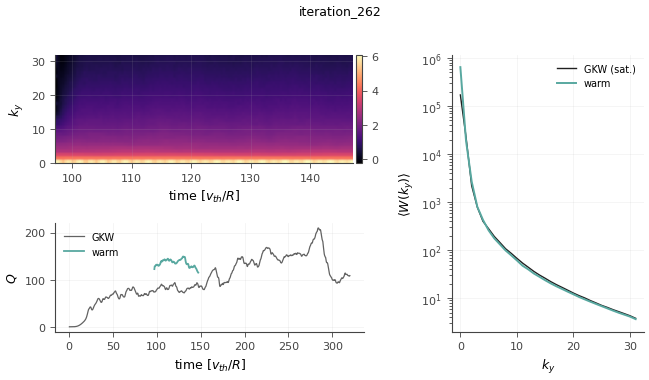

  saved iteration_135: {'pdf': PosixPath('/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/figs/paper/warm_overview_iteration_135.pdf'), 'png': PosixPath('/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/figs/paper/warm_overview_iteration_135.png')}


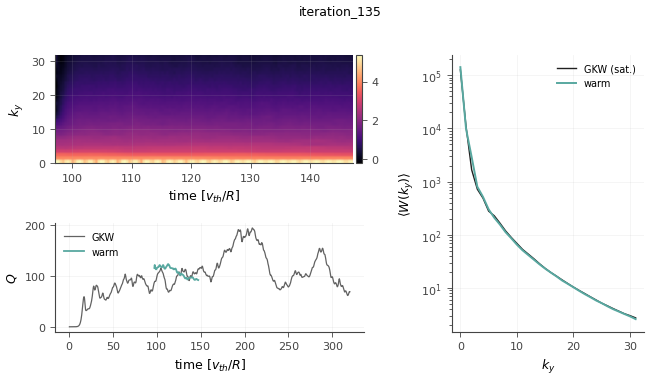

  saved iteration_8: {'pdf': PosixPath('/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/figs/paper/warm_overview_iteration_8.pdf'), 'png': PosixPath('/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/figs/paper/warm_overview_iteration_8.png')}


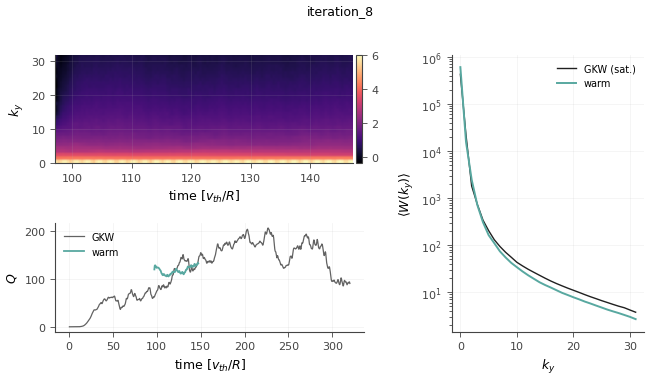

In [13]:
import numpy as np
import os
from matplotlib.gridspec import GridSpec

apply_paper_style()
QUAL_TRAJS = [t for t in warm_results if not t.startswith("ood_")][:3]
GKW_DT = 0.4   # raw GKW step in R/v_th
PAPER_QUAL = {}

for traj in QUAL_TRAJS:
    res = warm_results[traj]
    log_warm = res.get("log_warm", {})
    log_gt   = res.get("log_gt_ref", {})
    if "eflux" not in log_warm:
        print(f"  skip {traj}: no warm log")
        continue

    ky_warm = np.asarray(log_warm.get("ky_spec", []))
    ky_gt   = np.asarray(log_gt.get("ky_spec", []))
    warm_flux = np.asarray(log_warm["eflux"], dtype=float)
    t_warm = np.asarray(log_warm.get("time", []), dtype=float)

    # GT flux + time from raw files (works for ID + OOD).
    gkw_path = (os.path.join(GKW_RAW_DIR, "ood", traj[len("ood_"):])
                if traj.startswith("ood_iteration_")
                else os.path.join(GKW_RAW_DIR, traj))
    gt_full = None; t_gt = None
    p = os.path.join(gkw_path, "fluxes.dat")
    if os.path.isfile(p):
        gt_full = np.asarray(np.loadtxt(p)[:, 1], dtype=float)
    p = os.path.join(gkw_path, "time.dat")
    if os.path.isfile(p):
        t_gt = np.asarray(np.loadtxt(p), dtype=float)
    elif gt_full is not None:
        t_gt = np.arange(len(gt_full)) * GKW_DT

    fig = plt.figure(figsize=(7.6, 3.6))
    gs = GridSpec(2, 2, figure=fig, height_ratios=[1.0, 1.0],
                  width_ratios=[1.6, 1.0], hspace=0.55, wspace=0.35)
    ax_ky    = fig.add_subplot(gs[0, 0])
    ax_flux  = fig.add_subplot(gs[1, 0])
    ax_spec  = fig.add_subplot(gs[:, 1])

    # (a) warm ky heatmap — x in physical time
    if ky_warm.ndim == 2 and ky_warm.size > 0:
        T = ky_warm.shape[0]
        x_extent = (float(t_warm[0]) if t_warm.size == T else 0.0,
                    float(t_warm[-1]) if t_warm.size == T else float(T))
        im = ax_ky.imshow(np.log10(np.maximum(ky_warm.T, 1e-30)),
                            aspect="auto", origin="lower", cmap="magma",
                            extent=[x_extent[0], x_extent[1], 0, ky_warm.shape[1]])
        ax_ky.set_xlabel(r"time $[v_{th}/R]$")
        ax_ky.set_ylabel(r"$k_y$")
        fig.colorbar(im, ax=ax_ky, fraction=0.025, pad=0.01)

    # (b) flux: warm + GT both on the SAME physical-time axis
    if gt_full is not None and t_gt is not None:
        ax_flux.plot(t_gt, gt_full, color=COLOR_REF, lw=0.9, alpha=0.7, label="GKW")
    if t_warm.size == len(warm_flux):
        ax_flux.plot(t_warm, warm_flux, color=COLOR_GYROFLOW, lw=1.3, label="warm")
    else:
        ax_flux.plot(np.arange(len(warm_flux)) * GKW_DT, warm_flux,
                       color=COLOR_GYROFLOW, lw=1.3, label="warm (assumed dt=0.4)")
    ax_flux.set_xlabel(r"time $[v_{th}/R]$")
    ax_flux.set_ylabel(r"$Q$")
    ax_flux.legend(fontsize=7, loc="best", frameon=False)

    # (c) time-averaged log-W(k_y) — warm vs GT-saturated tail
    if ky_warm.ndim == 2 and ky_warm.size and ky_gt.ndim == 2 and ky_gt.size:
        warm_mean = ky_warm.mean(axis=0)
        gt_mean   = ky_gt.mean(axis=0)
        kk = np.arange(len(warm_mean))
        ax_spec.semilogy(kk, np.maximum(gt_mean, 1e-30), color=COLOR_REF,
                          lw=1.0, label="GKW (sat.)")
        ax_spec.semilogy(kk, np.maximum(warm_mean, 1e-30), color=COLOR_GYROFLOW,
                          lw=1.4, label="warm")
        ax_spec.set_xlabel(r"$k_y$")
        ax_spec.set_ylabel(r"$\langle W(k_y) \rangle$")
        ax_spec.legend(fontsize=7, loc="best", frameon=False)
    else:
        ax_spec.text(0.5, 0.5, "no spectrum", transform=ax_spec.transAxes,
                       ha="center", va="center", fontsize=8)

    fig.suptitle(traj, fontsize=9, y=1.02)
    fig.tight_layout()
    paths = save_fig(fig, f"warm_overview_{traj}", RESULTS_DIR)
    print(f"  saved {traj}: {paths}")
    plt.show()

    PAPER_QUAL[traj] = {
        "warm_eflux":   warm_flux,
        "warm_time":    t_warm,
        "gt_full_flux": gt_full,
        "gt_time":      t_gt,
        "warm_kyspec":  ky_warm,
        "gt_kyspec":    ky_gt,
    }


saved Anderson–Darling: {'pdf': PosixPath('/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/figs/paper/ad_vs_fid_skip_middle.pdf'), 'png': PosixPath('/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/figs/paper/ad_vs_fid_skip_middle.png')}


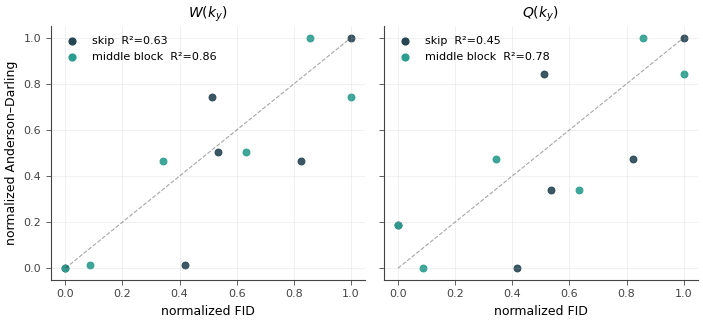

saved MMD: {'pdf': PosixPath('/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/figs/paper/mmd_vs_fid_skip_middle.pdf'), 'png': PosixPath('/system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/figs/paper/mmd_vs_fid_skip_middle.png')}


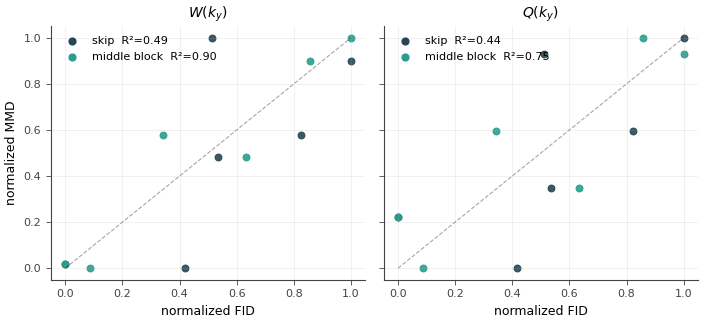


=== R²:  (measure, family) × FID level ===
level                      bottleneck  skip_deep
measure          family                         
Anderson–Darling fluxspec       0.777      0.446
                 ky_spec        0.863      0.631
MMD              fluxspec       0.747      0.437
                 ky_spec        0.903      0.491


In [14]:
# === Anderson-Darling + MMD vs FID: skip + middle block ===================
# Two families x two FID levels, the two whose K_GEN-noise floor is well
# below the traj-to-traj spread (per fid_split_half_diag) and which the
# correlation table currently picks as the strongest predictors.
per_iter_fids = globals().get("per_iter_fids", {})
warm_results  = globals().get("warm_results", {})
if not per_iter_fids or not warm_results:
    raise RuntimeError("run cell 28 + latent_dashboard first")

LEVELS = {
    "skip_deep":  ("skip",         "#264653"),
    "bottleneck": ("middle block", "#2a9d8f"),
}
FAMILY_LABELS = {"ky_spec": r"$W(k_y)$", "fluxspec": r"$Q(k_y)$"}

MEASURES_TO_PLOT = {
    "Anderson–Darling": {"ky_spec": "ky_spec_ad_mean",  "fluxspec": "fluxspec_ad_mean"},
    "MMD":              {"ky_spec": "ky_spec_mmd_mean", "fluxspec": "fluxspec_mmd_mean"},
}


def _norm01(arr):
    a = np.asarray(arr, dtype=float)
    finite = a[np.isfinite(a)]
    if finite.size == 0 or finite.max() == finite.min():
        return np.zeros_like(a)
    lo, hi = finite.min(), finite.max()
    return (a - lo) / (hi - lo)


trajs = [t for t in per_iter_fids if t in warm_results
          and warm_results[t].get("div_warm")]

apply_paper_style()
all_rows = []
for meas_label, fam_keys in MEASURES_TO_PLOT.items():
    fig, axes = plt.subplots(1, len(fam_keys),
                              figsize=(3.6 * len(fam_keys), 3.4),
                              sharey=True, squeeze=False)
    for col_i, (fam, mkey) in enumerate(fam_keys.items()):
        ax = axes[0, col_i]
        meas_vals = np.array([warm_results[t]["div_warm"].get(mkey, np.nan)
                               for t in trajs], dtype=float)
        meas_n = _norm01(meas_vals)
        for lv, (lv_label, lv_color) in LEVELS.items():
            fid_v = np.array([per_iter_fids[t].get(lv, np.nan) for t in trajs], dtype=float)
            fid_n = _norm01(fid_v)
            for j, t in enumerate(trajs):
                ax.scatter(fid_n[j], meas_n[j], s=24,
                            facecolor=lv_color, edgecolor=lv_color,
                            lw=0.8, marker="o", alpha=0.9)
            mask = np.isfinite(fid_v) & np.isfinite(meas_vals)
            if mask.sum() >= 3 and np.std(fid_v[mask]) > 0 and np.std(meas_vals[mask]) > 0:
                r = float(np.corrcoef(fid_v[mask], meas_vals[mask])[0, 1])
                r2 = r ** 2
            else:
                r2 = np.nan
            all_rows.append({"measure": meas_label, "family": fam, "level": lv, "r2": r2})
            label = f"{lv_label}  R²={r2:.2f}" if np.isfinite(r2) else lv_label
            ax.scatter([], [], s=24, color=lv_color, edgecolor=lv_color, label=label)
        ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.35)
        ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel("normalized FID")
        if col_i == 0:
            ax.set_ylabel(f"normalized {meas_label}")
        ax.set_title(FAMILY_LABELS[fam], fontsize=10)
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8, loc="upper left", frameon=False)
    fig.tight_layout()
    slug = "ad" if meas_label.startswith("Ander") else "mmd"
    paths = save_fig(fig, f"{slug}_vs_fid_skip_middle", RESULTS_DIR)
    print(f"saved {meas_label}: {paths}")
    plt.show()

import pandas as _pd
ad_df = _pd.DataFrame(all_rows).pivot_table(index=["measure", "family"],
                                             columns="level", values="r2")
print("\n=== R²:  (measure, family) × FID level ===")
print(ad_df.to_string(float_format=lambda x: f"{x:.3f}"))

## Persist results for the cross-method comparison notebook

Dumps a single pickle keyed by `METHOD_NAME` containing FIDs, distributional
metrics, summary tables, and qualitative arrays. Loaded by
`neurips_compare_methods.ipynb` to render multi-method tables/plots in the
same paper style.

In [15]:
# === persist all paper-figure data for the cross-method notebook ===========
import numpy as np

ID_trajs  = [t for t in warm_results if not t.startswith("ood_")]
OOD_trajs = [t for t in warm_results if     t.startswith("ood_")]

payload = {
    "method":       METHOD_NAME,
    "n_traj":       len(warm_results),
    "ID_trajs":     ID_trajs,
    "OOD_trajs":    OOD_trajs,
    "fids":         {lv: {t: float(per_iter_fids[t][lv])
                            for t in per_iter_fids if lv in per_iter_fids[t]}
                       for lv in {lv for d in per_iter_fids.values() for lv in d}},
    "metrics":      {col: div_df[col].to_dict() for col in div_df.columns
                       if col != "split"},
    "summary":      summary_df.to_dict(),
    "fid_summary":  fid_summary.to_dict(),
    "probe":        PAPER_PROBE if "PAPER_PROBE" in dir() else {},
    "metric_corr":  PAPER_METRIC_DATA if "PAPER_METRIC_DATA" in dir() else {},
    "qualitative": {
        "warm_eflux":   {t: PAPER_QUAL[t]["warm_eflux"]   for t in PAPER_QUAL},
        "gt_full_flux": {t: PAPER_QUAL[t]["gt_full_flux"] for t in PAPER_QUAL},
        "warm_kyspec":  {t: PAPER_QUAL[t]["warm_kyspec"]  for t in PAPER_QUAL},
        "gt_kyspec":    {t: PAPER_QUAL[t].get("gt_kyspec") for t in PAPER_QUAL},
    },
    "config": {
        "N_EVAL_STEPS":      N_EVAL_STEPS,
        "N_DENOISING_STEPS": N_DENOISING_STEPS,
        "FID_N_COMPONENTS":  FID_N_COMPONENTS,
        "PRETRAINED_DIR":    PRETRAINED_DIR,
        "AE_CHECKPOINT":     AE_CHECKPOINT,
        "GYROSWIN_CHECKPOINT": GYROSWIN_CHECKPOINT,
    },
}
path = save_method_results(METHOD_NAME, payload, RESULTS_DIR)
print(f"persisted method '{METHOD_NAME}' results to {path}")
print(f"keys: {sorted(payload.keys())}")


persisted method 'GyroFlow' results to /system/user/galletti/git/neural-gyrokinetics-gitlab/notebooks/figs/paper/GyroFlow.pkl
keys: ['ID_trajs', 'OOD_trajs', 'config', 'fid_summary', 'fids', 'method', 'metric_corr', 'metrics', 'n_traj', 'probe', 'qualitative', 'summary']
